# Generating single-sample networks with LIONESS - Geneformer edition

This notebook is used to create the single-sample networks (SSN) to be used in the training of GEA. The method is based on LIONESS and the resulting graphs are aggregated to the PPI network in order to have prior knowledge that can enrich each sample.

In [2]:
# Libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from transformers import BertModel, EsmModel
from tqdm import tqdm
from scipy import sparse
import torch
import networkx as nx
from typing import Dict, List, Tuple
import joblib
from torch_geometric.data import Data, DataLoader
from pybiomart import Server
from huggingface_hub import hf_hub_download
import pickle
import random
import torch.nn.functional as F
from torch import nn, optim
from torch_geometric.nn import GCNConv, global_mean_pool
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import umap

# Select project / dataset
project_id = "PRJNA248469"

gene_data = pd.read_csv(f"data/IBD_Andre_data_filtered/{project_id}_matrix_filtered.tsv", sep = "\t")
metadata = pd.read_csv(f"data/IBD_Andre_data_filtered/{project_id}_metadata.txt", sep = ",")
ppi_network = pd.read_csv(f"data/IBD_Andre_data_filtered/{project_id}_ppi_network.tsv", sep = "\t")

## Geneformer embeddings

To give the model information of each gene we are adding the Geneformer embedding as a feature in each node.

In [3]:
geneformer_output = "data/IBD_Andre_data_filtered/geneformer_static_embeddings.pt"
model_name = "ctheodoris/Geneformer"
genes = gene_data.iloc[:, 0].tolist()

# Mapping symbols to Ensembl IDs
server = Server(host="http://www.ensembl.org")
dataset = server.marts["ENSEMBL_MART_ENSEMBL"].datasets["hsapiens_gene_ensembl"]
mapping = dataset.query(attributes=["hgnc_symbol","ensembl_gene_id"])
mapping = mapping.rename(columns={"HGNC symbol": "symbol", "Gene stable ID": "ensembl_id"}).dropna()
symbol_to_ensembl = dict(zip(mapping["symbol"], mapping["ensembl_id"]))

# Load Geneformer model
try:
    model = BertModel.from_pretrained(model_name, output_hidden_states=True)
    model.eval()

    # Load vocabulary
    dict_path = hf_hub_download(repo_id=model_name, filename="token_dictionary_gc104M.pkl", subfolder="geneformer")
    with open(dict_path, "rb") as f:
        vocab = pickle.load(f)

except Exception as e:
    print(f"Error loading model or vocabulary: {e}")
    
# Extract embeddings for genes in the dataset
embedding_matrix = model.embeddings.word_embeddings.weight
hidden_dim = embedding_matrix.shape[1]

# Create tensor [num_genes, hidden_dim]
final_embeddings = torch.zeros((len(genes), hidden_dim))

found = 0

for i, gene in enumerate(tqdm(genes, desc="Extracting Geneformer embeddings")):
    ensembl_id = symbol_to_ensembl.get(gene)
    if ensembl_id and ensembl_id in vocab:
        token_id = vocab[ensembl_id]
        if token_id < embedding_matrix.shape[0]:  # Check if token_id is within bounds
            final_embeddings[i] = embedding_matrix[token_id]
            found += 1
        else:
            final_embeddings[i] = torch.randn(hidden_dim) # Random init for out-of-bounds token_id
    else:
        final_embeddings[i] = torch.randn(hidden_dim) # Random init for missing genes

print(f"Found embeddings for {found}/{len(genes)} genes.")
os.makedirs(os.path.dirname(geneformer_output), exist_ok=True)
torch.save(final_embeddings, geneformer_output)

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ctheodoris/Geneformer
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting Geneformer embeddings: 100%|██████████| 1165/1165 [00:00<00:00, 45017.77it/s]

Found embeddings for 1154/1165 genes.


## Gene co-expression matrix

First things first, we need to get the co-expression matrix for our whole dataset. To do so, we normalize the data first and after we compute the correlation for each pair of genes (both Pearson and Spearman will be used to compare final results of the whole pipeline).

In [4]:
# Get gene count data into format
gene_data_t = gene_data.rename(columns={"gene_symbol":"samples"}).set_index("samples").T

# Normalize data (log2 CPM)
lib_size = gene_data_t.sum(axis=1)
if (lib_size == 0).any():
    raise ValueError("One or more samples have zero library size (not possible)")
cpm = gene_data_t.div(lib_size, axis=0) * 1e6
norm_data = np.log2(cpm + 1.0)

# Filter data that is from undesired phenotype group
rel_metadata = metadata[["BioSample", "source_name"]].rename(columns={"BioSample":"sample", "source_name":"phenotype"})
joint_data = rel_metadata.merge(norm_data, left_on="sample", right_index=True, how="inner")

# for project PRJNA565216
# joint_data = joint_data[joint_data["phenotype"].isin(["Control_Ileum", "Ulcerative Colitis_Ileum", "Crohn's Disease_Ileum"])].reset_index(drop=True)

# for project PRJNA248469
joint_data = joint_data[joint_data["phenotype"].str.contains("IBD|CD|UC")].reset_index(drop=True)
joint_data["phenotype"] = joint_data["phenotype"].str.split(",").str[-1].str.strip()
joint_data = joint_data.set_index("sample")

pearson_corrs = []
grouped_data = []

# Compute correlation per phenotype group
for phenotype in joint_data["phenotype"].unique():
    # Select data from phenotype group
    group_data = joint_data[joint_data["phenotype"] == phenotype].drop(columns="phenotype")
    grouped_data.append(group_data)
    # Correlation matrix - Pearson
    pearson_corr = group_data.corr(method="pearson")
    pearson_corrs.append(pearson_corr)

## LIONESS - A theoretical overview

LIONESS starts with the network $G$ built on all $N$ samples. For each sample $s$, the network built on all samples except that one is $G_{-s}$. Then, the sample-specific network $G_s$ is:

$$
G_{s} = N * G - (N-1) * G_{-s}
$$

If $G$ and $G_{-s}$ are correlation matrices, directly applying this may produce values outside $[-1,1]$, which can complicate interpretation. To avoid this, we will transform coefficients $r$ to Fisher-z space $\mathrm{atanh}(z)$. Because $\mathrm{atanh()}$ is a bijection from (-1, 1) -> $\mathbb{R}$ and $\mathrm{tanh()}$ is the inverse, any linear combination you form in z-space is guaranteed to map back to a value inside (-1, 1). Then:

$$
Z_{s} = N * Z - (N-1) * Z_{-s}
$$

$$
G_{s} = \mathrm{tanh}(Z_{s})
$$

## Aggregating PPI network to LIONESS framework

We now add the PPI network to informed each network of already-known interactions between genes. By doing this we will add an extra filtering step to discard any edge that isn't present in the network. This, however, just allows us to use known co-expressions and doesn't give the possibility to find new ones. First, we extract the edges from it.

In [5]:
# Extract edges from PPI network
ppi_edges = set()
for _, row in ppi_network.iterrows():
    edge = tuple(sorted((row["preferredName_A"], row["preferredName_B"])))
    ppi_edges.add(edge)

print(f"A total of {len(ppi_edges)} unique interaction are present in the PPI network.")

A total of 7829 unique interaction are present in the PPI network.


Now that we have the edges we compute the LIONESS framework, retaining only the PPI edges.

In [6]:
sample_edges_pearson = {}

for i, group_data in enumerate(grouped_data):
    # Relevant data
    samples = group_data.index.tolist()
    genes = group_data.columns.tolist()
    N = group_data.shape[0]
    threshold = 0.25

    # Correlations
    pearson_corr = pearson_corrs[i]

    # Mapping from gene to index
    gene_to_idx = {gene: i for i, gene in enumerate(genes)}

    # Get indices for the edges that are in our PPI network
    ppi_indices = []
    ppi_gene_pairs = []
    for gene_a, gene_b in ppi_edges:
        if gene_a in gene_to_idx and gene_b in gene_to_idx:
            idx_a = gene_to_idx[gene_a]
            idx_b = gene_to_idx[gene_b]
            # Ensure i < j
            ppi_indices.append((min(idx_a, idx_b), max(idx_a,idx_b)))
            ppi_gene_pairs.append((gene_a, gene_b))

    # Fisher z of G
    G_pearson = pearson_corr.values
    Z_pearson = np.arctanh(np.clip(G_pearson, -1 + 1e-12, 1 - 1e-12)) # clipping to avoid arctanh(1) or arctanh(-1)

    # Iterate on all samples, leave-one-out G_{-s} correlation and LIONESS in z-space
    for _, s in enumerate(tqdm(samples, desc="LIONESS samples (PPI filtered)")):
        # Drop s
        data_minus_s = group_data.drop(index=s)

        # Correlation on N-1 samples
        G_minus_s_pearson = data_minus_s.corr(method="pearson").values

        # Z-space
        Z_minus_s_pearson = np.arctanh(np.clip(G_minus_s_pearson, -1 + 1e-12, 1 - 1e-12))

        # LIONESS
        Z_s_pearson = N * Z_pearson - (N - 1) * Z_minus_s_pearson

        # PPI filtering step: extract weights for just the PPI edges
        Z_s_ppi_pearson = np.array([Z_s_pearson[i,j] for (i,j) in ppi_indices])

        # Back to r-space
        G_s_ppi_pearson = np.tanh(Z_s_ppi_pearson)

        # Filter correlations under threshold
        keep_mask_pearson = np.abs(G_s_ppi_pearson) >= threshold

        # DataFrame for kept edges
        kept_pairs_pearson = [ppi_gene_pairs[i] for i in np.where(keep_mask_pearson)[0]]
        kept_weights_pearson = G_s_ppi_pearson[keep_mask_pearson]
        edges_pearson = pd.DataFrame({
            "geneA": [p[0] for p in kept_pairs_pearson],
            "geneB": [p[1] for p in kept_pairs_pearson],
            "weight": kept_weights_pearson
        })
        sample_edges_pearson[s] = edges_pearson.reset_index(drop = True)

LIONESS samples (PPI filtered):   0%|          | 0/204 [00:00<?, ?it/s]

LIONESS samples (PPI filtered): 100%|██████████| 59/59 [00:09<00:00,  6.04it/s]


## Save into NetworkX and PyTorch Geometric objects

Now we have our training dataset, we are going to turned it into NetworkX graphs for easy introspection and PyTorch Geometric data for GNN training. First we define the functions that are going to be used for this.

In [7]:
# Build PyG data objects. Node features x are the expression values for that sample.
def sample_edges_to_rgcn_pyg(sample_edges, norm_data, genes, gene_to_idx, static_embeddings, bio_to_source, label_map):
    data_list = []
    static_embeddings = static_embeddings.cpu() # Ensure CPU

    for s, df in tqdm(sample_edges.items(), desc="Building R-GCN Objects"):
        if s not in norm_data.index: continue
        
        # 1. Node Features: [Expression (1) + Geneformer (Hidden_Dim)]
        expr = norm_data.loc[s, genes].values.astype(np.float32).reshape(-1,1)
        expr_tensor = torch.from_numpy(expr)
        # Concatenate features
        x = torch.cat([expr_tensor, static_embeddings], dim=1)

        # 2. Process Edges for R-GCN
        # Type 0 = Positive, Type 1 = Negative
        edges = []
        edge_types = []
        edge_weights = []

        for _, row in df.iterrows():
            a, b, w = row["geneA"], row["geneB"], float(row["weight"])
            if a not in gene_to_idx or b not in gene_to_idx: continue
            
            i, j = gene_to_idx[a], gene_to_idx[b]
            w_abs = abs(w)
            e_type = 0 if w > 0 else 1

            # Undirected graph: Add both directions
            edges.extend([[i, j], [j, i]])
            edge_types.extend([e_type, e_type])
            edge_weights.extend([w_abs, w_abs])

        if not edges: continue # Skip empty graphs

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_type = torch.tensor(edge_types, dtype=torch.long)
        edge_attr = torch.tensor(edge_weights, dtype=torch.float32)

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.edge_type = edge_type
        data.sample_name = s
        
        # Label
        src = bio_to_source[s]
        data.y = torch.tensor(label_map[src], dtype=torch.long)
        
        data_list.append(data)
    
    return data_list

In [8]:
# Load embeddings and build PyG objects
static_embeddings = torch.load(geneformer_output)
bio_to_source = joint_data["phenotype"].to_dict()
label_names = sorted(joint_data["phenotype"].unique())
label_map = {lab: i for i, lab in enumerate(label_names)}

data_list = sample_edges_to_rgcn_pyg(
    sample_edges_pearson,
    norm_data,
    genes,
    gene_to_idx,
    static_embeddings,
    bio_to_source,
    label_map
)

# Save PyG objects
train_loader = DataLoader(data_list, batch_size=32, shuffle=True)
embed_loader = DataLoader(data_list, batch_size=32, shuffle=False)

Building R-GCN Objects: 100%|██████████| 303/303 [01:09<00:00,  4.35it/s]
/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


# R-GCN model

## Defining the model and training loop

In [9]:
class WeightedRGCNLayer(nn.Module):
    """Split edges by positive vs negative weight, and aggregates."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_pos = GCNConv(in_channels, out_channels)
        self.conv_neg = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index, edge_type, edge_weight):
        # Mask
        pos_mask = (edge_type == 0)
        neg_mask = (edge_type == 1)

        # Positive stream
        if pos_mask.any():
            pos_out = self.conv_pos(x, edge_index[:, pos_mask], edge_weight[pos_mask])
        else:
            pos_out = torch.zeros(x.size(0), self.conv_pos.out_channels, device=x.device)

        # Negative stream
        if neg_mask.any():
            neg_out = self.conv_neg(x, edge_index[:, neg_mask], edge_weight[neg_mask])
        else:
            neg_out = torch.zeros(x.size(0), self.conv_neg.out_channels, device=x.device)

        return pos_out + neg_out
    
# class RGCN(nn.Module):
#     def __init__(self, in_channels, hidden_channels, latent_dim, n_classes, dropout=0.2):
#         super().__init__()
#         self.dropout = dropout
        
#         self.layer1 = WeightedRGCNLayer(in_channels, hidden_channels)
#         self.layer2 = WeightedRGCNLayer(hidden_channels, hidden_channels)
#         self.layer3 = WeightedRGCNLayer(hidden_channels, latent_dim)
        
#         self.classifier = nn.Sequential(
#             nn.Linear(latent_dim, latent_dim // 2),
#             nn.ReLU(),
#             nn.Linear(latent_dim // 2, n_classes)
#         )

#     def forward(self, data):
#         x, edge_index, edge_type, edge_attr = data.x, data.edge_index, data.edge_type, data.edge_attr
        
#         # Encode
#         h = self.layer1(x, edge_index, edge_type, edge_attr)
#         h = F.relu(h)
#         h = F.dropout(h, p=self.dropout, training=self.training)
        
#         h = self.layer2(h, edge_index, edge_type, edge_attr)
#         h = F.relu(h)
#         h = F.dropout(h, p=self.dropout, training=self.training)
        
#         z_node = self.layer3(h, edge_index, edge_type, edge_attr) # Node Latents
        
#         # Pool
#         z_graph = global_mean_pool(z_node, data.batch) # Graph Latent
        
#         # Classify
#         logits = self.classifier(z_graph)
        
#         return z_graph, logits
    
class RGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_dim, n_classes, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        
        self.layer1 = WeightedRGCNLayer(in_channels, hidden_channels)
        self.layer2 = WeightedRGCNLayer(hidden_channels, hidden_channels)
        self.layer3 = WeightedRGCNLayer(hidden_channels, latent_dim)
        
        # Classifier objective: predict phenotype from graph latent
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.ReLU(),
            nn.Linear(latent_dim // 2, n_classes)
        )

        # Decoder objective: reconstruct original edge weights from node latents
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim * 2, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_type, edge_attr = data.x, data.edge_index, data.edge_type, data.edge_attr
        
        # Encode
        h = self.layer1(x, edge_index, edge_type, edge_attr)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        h = self.layer2(h, edge_index, edge_type, edge_attr)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        z_node = self.layer3(h, edge_index, edge_type, edge_attr) # Node Latents
        
        # Pool
        z_graph = global_mean_pool(z_node, data.batch) # Graph Latent
        
        # Classify
        logits = self.classifier(z_graph)

        # Decode
        src, dst = edge_index[0], edge_index[1]
        edge_features = torch.cat([z_node[src], z_node[dst]], dim=1) # [num_edges, latent_dim*2]
        recon_weights = self.decoder(edge_features).squeeze() # [num_edges]
        
        # MODIFIED: Return z_node as well
        return z_node, z_graph, logits, recon_weights

def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Input Dim = 1 (Expr) + Geneformer Dim
    in_dim = data_list[0].x.shape[1]
    n_classes = len(label_names)
    
    model = RGCN(in_channels=in_dim,
                hidden_channels=128,
                latent_dim=64,
                n_classes=n_classes).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    cls_criterion = nn.CrossEntropyLoss()
    cls_weight = 1.0
    recon_criterion = nn.MSELoss()
    recon_weight = 0.5
    
    print("Starting Training...")
    epochs = 100
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_cls_loss = 0
        total_recon_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            _, _, logits, recon_weights = model(batch)
            
            # Loss: Classification
            loss_cls = cls_criterion(logits, batch.y)

            # Loss: Reconstruction
            loss_recon = recon_criterion(recon_weights, batch.edge_attr)

            loss = cls_weight * loss_cls + recon_weight * loss_recon
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_cls_loss += loss_cls.item()
            total_recon_loss += loss_recon.item()
            
        if (epoch+1) % 10 == 0:
            avg_loss = total_loss / len(train_loader)
            avg_cls = total_cls_loss / len(train_loader)
            avg_recon = total_recon_loss / len(train_loader)
            print(f"Epoch {epoch+1}: Total Loss {avg_loss:.4f} | Cls: {avg_cls:.4f} | Recon: {avg_recon:.4f}")

    return model, device

## Training the model

In [10]:
# set random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

#training model
model, device = train()

Starting Training...
Epoch 10: Total Loss 0.8784 | Cls: 0.8515 | Recon: 0.0537
Epoch 20: Total Loss 0.6171 | Cls: 0.5925 | Recon: 0.0493
Epoch 30: Total Loss 0.3874 | Cls: 0.3658 | Recon: 0.0430
Epoch 40: Total Loss 0.2804 | Cls: 0.2594 | Recon: 0.0420
Epoch 50: Total Loss 0.2077 | Cls: 0.1866 | Recon: 0.0421
Epoch 60: Total Loss 0.1512 | Cls: 0.1308 | Recon: 0.0409
Epoch 70: Total Loss 0.1008 | Cls: 0.0802 | Recon: 0.0412
Epoch 80: Total Loss 0.1173 | Cls: 0.0964 | Recon: 0.0419
Epoch 90: Total Loss 0.1266 | Cls: 0.1058 | Recon: 0.0416
Epoch 100: Total Loss 0.0396 | Cls: 0.0193 | Recon: 0.0405


## UMAP visualization of embeddings

Extracting Embeddings for UMAP...


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


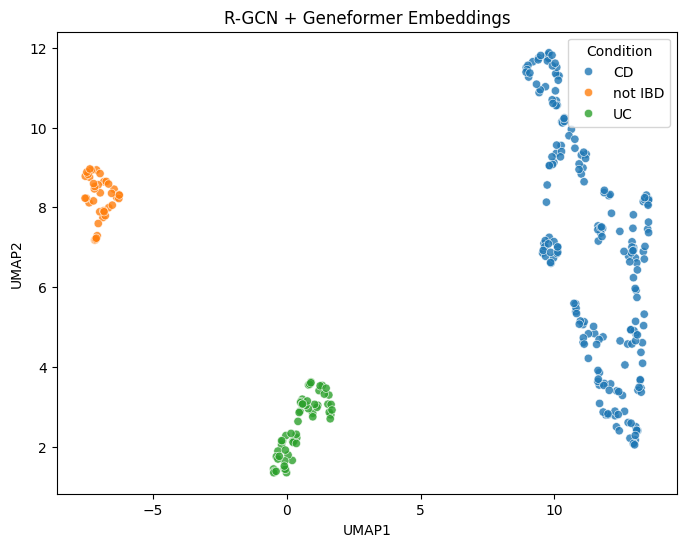

In [11]:
print("Extracting Embeddings for UMAP...")
model.eval()
embeddings = []
labels = []

with torch.no_grad():
    for batch in embed_loader:
        batch = batch.to(device)
        _, z_graph, _, _= model(batch)
        embeddings.append(z_graph.cpu().numpy())
        labels.extend([label_names[y] for y in batch.y.cpu().numpy()])
        
X_emb = np.concatenate(embeddings, axis=0)

reducer = umap.UMAP(n_components=2, random_state=42)
umap_coords = reducer.fit_transform(X_emb)

df_plot = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
df_plot["Condition"] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x="UMAP1", y="UMAP2", hue="Condition", alpha=0.8)
plt.title("R-GCN + Geneformer Embeddings")
plt.show()

## Getting node- and graph-level embeddings

In [12]:
print("Extracting and saving final embeddings...")
model.eval()

# Dictionaries to store embeddings keyed by sample name
node_embeddings_dict = {}
graph_embeddings_dict = {}

with torch.no_grad():
    for batch in tqdm(embed_loader, desc="Extracting"):
        batch = batch.to(device)
        
        # Get latents
        z_node, z_graph, _, _ = model(batch)
        
        # Move back to CPU and convert to numpy
        z_graph_np = z_graph.cpu().numpy()
        z_node_tensor = z_node.cpu()
        batch_index = batch.batch.cpu()
        
        # Split the concatenated node tensor by graph
        z_node_split = [z_node_tensor[batch_index == i].numpy() for i in range(batch.num_graphs)]
        
        # Map back to sample names
        for i in range(batch.num_graphs):
            # PyG handles lists of strings in batching by passing them through directly
            sample_id = batch.sample_name[i] 
            
            graph_embeddings_dict[sample_id] = z_graph_np[i]
            node_embeddings_dict[sample_id] = z_node_split[i]

# Save to disk
output_dir = "data/IBD_Andre_data_filtered/embeddings"
os.makedirs(output_dir, exist_ok=True)

graph_output_path = os.path.join(output_dir, "rgcn_graph_embeddings.pt")
node_output_path = os.path.join(output_dir, "rgcn_node_embeddings.pt")

torch.save(graph_embeddings_dict, graph_output_path)
torch.save(node_embeddings_dict, node_output_path)

print(f"Successfully saved graph embeddings to {graph_output_path}")
print(f"Successfully saved node embeddings to {node_output_path}")

Extracting and saving final embeddings...


Extracting: 100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


Successfully saved graph embeddings to data/IBD_Andre_data_filtered/embeddings/rgcn_graph_embeddings.pt
Successfully saved node embeddings to data/IBD_Andre_data_filtered/embeddings/rgcn_node_embeddings.pt


# GEA: Graph Explainable Attribution

## Sparse Autoencoder with graph-level embeddings

### Functions

In [22]:
from torch.utils.data import Dataset, DataLoader

# Dataset loader for saved embeddings from GNN model
class EmbeddingDataset(Dataset):
    def __init__(self, pt_file_path):
        """
        Loads a dictionary of {sample_id: embedding_array} 
        and converts it into a flat PyTorch Dataset.
        """
        self.data_dict = torch.load(pt_file_path, weights_only=False)
        self.sample_ids = list(self.data_dict.keys())
        
        # Convert numpy arrays to torch tensors
        self.embeddings = [torch.tensor(self.data_dict[sid], dtype=torch.float32) 
                           for sid in self.sample_ids]
        
    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.sample_ids[idx]

# Sparse Autoencoder 
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, expansion_factor=4):
        super().__init__()
        
        # hidden dimension is larger than the input
        self.hidden_dim = input_dim * expansion_factor
        
        # Encoder: Maps input to an overcomplete latent space
        self.encoder = nn.Linear(input_dim, self.hidden_dim)
        
        # Decoder: Maps sparse latents back to the original embedding space
        self.decoder = nn.Linear(self.hidden_dim, input_dim)
        
        # Initialize weights (Xavier initialization for better convergence)
        nn.init.xavier_uniform_(self.decoder.weight)

    def forward(self, x):
        # Forward pass
        z = torch.relu(self.encoder(x))
        
        # Reconstruct the original embedding
        x_recon = self.decoder(z)
        
        return z, x_recon

# Training loop
def train_sae(data_path, expansion_factor=4, l1_coeff=1e-3, batch_size=32, epochs=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load Data
    dataset = EmbeddingDataset(data_path)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Determine input dimension from the first sample
    input_dim = dataset[0][0].shape[0]
    
    # Initialize Model
    model = SparseAutoencoder(input_dim, expansion_factor).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Loss function for reconstruction
    recon_criterion = nn.MSELoss()
    
    print(f"Starting SAE Training on device: {device}")
    print(f"Input Dim: {input_dim} | Sparse Latent Dim: {input_dim * expansion_factor}")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_recon = 0
        total_l1 = 0
        
        for x, _ in dataloader:
            x = x.to(device)
            optimizer.zero_grad()
            
            # Forward pass
            z, x_recon = model(x)
            
            # 1. Reconstruction Loss (MSE)
            loss_recon = recon_criterion(x_recon, x)
            
            # 2. Sparsity Loss (L1 norm of the latent activations)
            loss_l1 = l1_coeff * torch.mean(torch.sum(torch.abs(z), dim=1))
            
            # Combined Loss
            loss = loss_recon + loss_l1
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_recon += loss_recon.item()
            total_l1 += loss_l1.item()
            
        if (epoch + 1) % 100 == 0:
            avg_recon = total_recon / len(dataloader)
            avg_l1 = total_l1 / len(dataloader)
            print(f"Epoch {epoch+1:03d} | Total: {total_loss/len(dataloader):.4f} | "
                  f"MSE: {avg_recon:.4f} | L1 Penalty: {avg_l1:.4f}")
            
    return model, device

def extract_sparse_activations(sae_model, data_path, device):
    """Passes all embeddings through the SAE to get the sparse latents (z)."""
    sae_model.eval()
    
    # Load dataset with weights_only=False (matching our previous fix)
    data_dict = torch.load(data_path, weights_only=False)
    sample_ids = list(data_dict.keys())
    
    activations = []
    
    with torch.no_grad():
        for sid in sample_ids:
            x = torch.tensor(data_dict[sid], dtype=torch.float32).unsqueeze(0).to(device)
            z, _ = sae_model(x)
            activations.append(z.cpu().squeeze().numpy())
            
    # Create a DataFrame where rows are samples and columns are SAE features
    feature_names = [f"Feature_{i}" for i in range(activations[0].shape[0])]
    df_activations = pd.DataFrame(activations, index=sample_ids, columns=feature_names)
    
    return df_activations

def run_differential_activation(df_activations, metadata_df, group_col, group1, group2):
    """
    Compares SAE feature activations between two groups using Mann-Whitney U test.
    """
    # Merge activations with phenotype labels
    df_merged = df_activations.merge(metadata_df[[group_col]], left_index=True, right_index=True, how='inner')
    
    # Filter for the two groups we are comparing
    df_subset = df_merged[df_merged[group_col].isin([group1, group2])]
    
    group1_data = df_subset[df_subset[group_col] == group1].drop(columns=[group_col])
    group2_data = df_subset[df_subset[group_col] == group2].drop(columns=[group_col])
    
    results = []
    features = group1_data.columns
    
    for feat in features:
        g1_vals = group1_data[feat].values
        g2_vals = group2_data[feat].values
        
        # Calculate effect size (difference in means)
        mean_diff = g1_vals.mean() - g2_vals.mean()
        
        # Calculate sparsity (percentage of non-zero activations in each group)
        g1_active_pct = (g1_vals > 0).mean() * 100
        g2_active_pct = (g2_vals > 0).mean() * 100
        
        # Only test if at least one group has some activation (prevents testing dead neurons)
        if g1_active_pct > 0 or g2_active_pct > 0:
            # Mann-Whitney U test
            stat, pval = mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
        else:
            pval = np.nan
            
        results.append({
            "Feature": feat,
            f"{group1}_Mean": g1_vals.mean(),
            f"{group2}_Mean": g2_vals.mean(),
            "Mean_Diff": mean_diff,
            f"{group1}_Active_%": g1_active_pct,
            f"{group2}_Active_%": g2_active_pct,
            "p_value": pval
        })
        
    res_df = pd.DataFrame(results).dropna(subset=["p_value"])
    
    # FDR Correction (Benjamini-Hochberg)
    _, res_df["adj_p_value"], _, _ = multipletests(res_df["p_value"], alpha=0.05, method='fdr_bh')
    
    # Sort by adjusted p-value
    res_df = res_df.sort_values("adj_p_value")
    return res_df, df_subset

def attribute_sae_feature_to_graph(data, rgcn_model, sae_model, feature_idx, genes, gene_to_idx):
    """
    Computes Input x Gradient attribution for a specific SAE feature 
    to find the driving nodes (genes) and edges in a single sample graph.
    """
    rgcn_model.eval()
    sae_model.eval()
    
    # --- NEW: Detect the device your model is on ---
    device = next(rgcn_model.parameters()).device
    
    # 1. Move inputs to the correct device AND enable gradients
    x = data.x.to(device).clone().detach().requires_grad_(True)
    edge_attr = data.edge_attr.to(device).clone().detach().requires_grad_(True)
    
    # Move the indexing tensors to the device as well
    edge_index = data.edge_index.to(device)
    edge_type = data.edge_type.to(device)
    
    # Create a dummy batch vector on the correct device
    batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
    
    # 2. Forward pass through R-GCN (using our device-mapped tensors)
    h = rgcn_model.layer1(x, edge_index, edge_type, edge_attr)
    h = torch.nn.functional.relu(h)
    h = rgcn_model.layer2(h, edge_index, edge_type, edge_attr)
    h = torch.nn.functional.relu(h)
    z_node = rgcn_model.layer3(h, edge_index, edge_type, edge_attr)
    
    from torch_geometric.nn import global_mean_pool
    z_graph = global_mean_pool(z_node, batch)
    
    # 3. Forward pass through SAE Encoder
    sae_z = torch.relu(sae_model.encoder(z_graph))
    
    # 4. Target the specific SAE feature we care about
    target_activation = sae_z[0, feature_idx]
    
    # If the feature didn't activate for this graph, gradients will be zero
    if target_activation <= 0:
        return None, None
        
    # 5. Compute Gradients
    target_activation.backward()
    
    # 6. Input x Gradient Calculation
    # Node attribution
    node_attribution = (x * x.grad).sum(dim=1).detach().cpu().numpy()
    
    # Edge attribution
    edge_attribution = (edge_attr * edge_attr.grad).detach().cpu().numpy()
    
    # 7. Format Results
    idx_to_gene = {v: k for k, v in gene_to_idx.items()}
    
    node_results = pd.DataFrame({
        "Gene": [idx_to_gene.get(i, f"Node_{i}") for i in range(len(node_attribution))],
        "Attribution_Score": node_attribution
    }).sort_values(by="Attribution_Score", key=abs, ascending=False)
    
    # Format edge results
    src, dst = edge_index.cpu().numpy()
    edge_results = pd.DataFrame({
        "Gene_A": [idx_to_gene.get(i, f"Node_{i}") for i in src],
        "Gene_B": [idx_to_gene.get(i, f"Node_{i}") for i in dst],
        "Attribution_Score": edge_attribution,
        "Original_Weight": edge_attr.detach().cpu().numpy()
    }).sort_values(by="Attribution_Score", key=abs, ascending=False)
    
    # Deduplicate undirected edges
    edge_results["Edge_ID"] = edge_results.apply(
        lambda row: tuple(sorted([row["Gene_A"], row["Gene_B"]])), axis=1
    )
    edge_results = edge_results.drop_duplicates(subset=["Edge_ID"]).drop(columns=["Edge_ID"])
    
    return node_results, edge_results

def get_consensus_attribution(sae_feature_name, patient_ids, data_list, rgcn_model, sae_model, genes, gene_to_idx):
    """
    Runs attribution for a specific SAE feature across a group of patients
    and averages the gene and edge importance scores.
    """
    # Extract the integer index (e.g., "Feature_42" -> 42)
    feature_idx = int(sae_feature_name.split("_")[1])
    
    all_node_res = []
    
    print(f"Aggregating attributions for {sae_feature_name}...")
    for patient_id in tqdm(patient_ids):
        # Find the PyG Data object for this patient
        patient_data = next((data for data in data_list if data.sample_name == patient_id), None)
        if patient_data is None:
            continue
            
        # Run attribution (using the function from our previous step)
        node_res, _ = attribute_sae_feature_to_graph(
            patient_data, rgcn_model, sae_model, feature_idx, genes, gene_to_idx
        )
        
        if node_res is not None:
            all_node_res.append(node_res.set_index("Gene")["Attribution_Score"])
            
    # Combine and average across all patients
    if not all_node_res:
        return None
        
    consensus_nodes = pd.concat(all_node_res, axis=1).mean(axis=1).reset_index()
    consensus_nodes.columns = ["Gene", "Mean_Attribution"]
    consensus_nodes = consensus_nodes.sort_values(by="Mean_Attribution", key=abs, ascending=False)
    
    return consensus_nodes

### Training SAE

In [24]:
# Load embeddings
graph_embeddings_path = "data/IBD_Andre_data_filtered/embeddings/rgcn_graph_embeddings.pt"

# Random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    
# Train model
sae_model, device = train_sae(graph_embeddings_path, expansion_factor=8, l1_coeff=1e-3, batch_size=32, epochs=1000)

Starting SAE Training on device: cuda
Input Dim: 64 | Sparse Latent Dim: 512
Epoch 100 | Total: 0.0070 | MSE: 0.0002 | L1 Penalty: 0.0068
Epoch 200 | Total: 0.0043 | MSE: 0.0001 | L1 Penalty: 0.0042
Epoch 300 | Total: 0.0033 | MSE: 0.0001 | L1 Penalty: 0.0032
Epoch 400 | Total: 0.0028 | MSE: 0.0002 | L1 Penalty: 0.0026
Epoch 500 | Total: 0.0024 | MSE: 0.0002 | L1 Penalty: 0.0022
Epoch 600 | Total: 0.0021 | MSE: 0.0001 | L1 Penalty: 0.0020
Epoch 700 | Total: 0.0020 | MSE: 0.0002 | L1 Penalty: 0.0018
Epoch 800 | Total: 0.0017 | MSE: 0.0001 | L1 Penalty: 0.0016
Epoch 900 | Total: 0.0016 | MSE: 0.0001 | L1 Penalty: 0.0014
Epoch 1000 | Total: 0.0014 | MSE: 0.0001 | L1 Penalty: 0.0013


### Differential Activation Analysis

Comparing CD vs not IBD...

Top 5 Enriched Features:
         Feature   CD_Mean  not IBD_Mean  Mean_Diff  CD_Active_%  \
158  Feature_158  0.000000      0.149559  -0.149559     0.000000   
28    Feature_28  0.221979      0.762872  -0.540893    99.509804   
316  Feature_316  0.895752      0.003232   0.892521   100.000000   
93    Feature_93  0.271591      0.227080   0.044511    98.529412   

     not IBD_Active_%       p_value   adj_p_value  
158              77.5  7.219904e-41  2.887962e-40  
28              100.0  1.607854e-23  2.143805e-23  
316              10.0  1.366856e-23  2.143805e-23  
93               97.5  1.382762e-01  1.382762e-01  


/tmp/ipykernel_363695/1383496273.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=merged_data, x="phenotype", y=top_feature, inner="stick", palette="Set2")


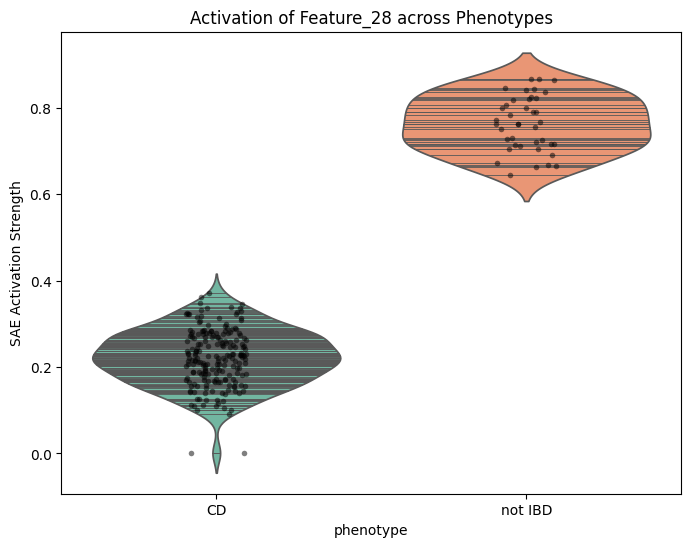

In [25]:
df_z = extract_sparse_activations(sae_model, graph_embeddings_path, device)

metadata_df = joint_data[["phenotype"]]

# Run Differential Analysis 
disease_label = "CD"
control_label = "not IBD"

print(f"Comparing {disease_label} vs {control_label}...")
diff_results, merged_data = run_differential_activation(
    df_z, metadata_df, group_col="phenotype", group1=disease_label, group2=control_label
)

print("\nTop 5 Enriched Features:")
print(diff_results.head(5))

# Plot the top feature
top_feature = diff_results.iloc[1]["Feature"]

plt.figure(figsize=(8, 6))
sns.violinplot(data=merged_data, x="phenotype", y=top_feature, inner="stick", palette="Set2")
sns.stripplot(data=merged_data, x="phenotype", y=top_feature, color='black', alpha=0.5, size=4)
plt.title(f"Activation of {top_feature} across Phenotypes")
plt.ylabel("SAE Activation Strength")
plt.show()

### Consensus attribution of DA features

In [26]:
# 1. Get the name of your #1 feature from the diff_results dataframe
top_feature = diff_results.iloc[1]["Feature"]

# 2. Get the list of patient IDs who actually have the disease
disease_patients = merged_data[merged_data["phenotype"] == disease_label].index.tolist()

# 3. Run the consensus attribution
consensus_genes = get_consensus_attribution(
    top_feature, disease_patients, data_list, model, sae_model, genes, gene_to_idx
)

print(f"\nTop 10 Genes driving {top_feature}:")
print(consensus_genes.head(10))

Aggregating attributions for Feature_28...


100%|██████████| 204/204 [00:24<00:00,  8.18it/s]


Top 10 Genes driving Feature_28:
            Gene  Mean_Attribution
2            LTB         -0.054985
0            TNF          0.049265
3         SLC9A3          0.030931
1           TNXB          0.028765
5        SYNGAP1          0.027493
4   LOC102723407         -0.022997
30          APOM         -0.020783
6       APOBEC3A          0.019404
61        CYP3A4         -0.012301
11          APOB         -0.011423


### GSEA on top genes

Running Pre-ranked GSEA... This might take a minute.

Top 10 Enriched Pathways for Feature_28:
                                                 Term       NES FDR q-val
0   GO_Biological_Process_2023__Cellular Response ...  2.142332  0.020921
1   GO_Biological_Process_2023__Positive Regulatio...  2.132354  0.015691
2              KEGG_2021_Human__TNF signaling pathway  2.130261  0.010959
3   GO_Biological_Process_2023__Regulation Of Cell...  2.129816  0.008219
4   GO_Biological_Process_2023__Cellular Response ...  2.116726  0.007771
5                      KEGG_2021_Human__Legionellosis    2.0885  0.011706
6            KEGG_2021_Human__IL-17 signaling pathway  2.079448  0.014517
7                        KEGG_2021_Human__Influenza A  2.075442  0.014383
8   Reactome_2022__Interleukin-10 Signaling R-HSA-...  2.073187  0.013283
10                           KEGG_2021_Human__Malaria  2.056083   0.01853


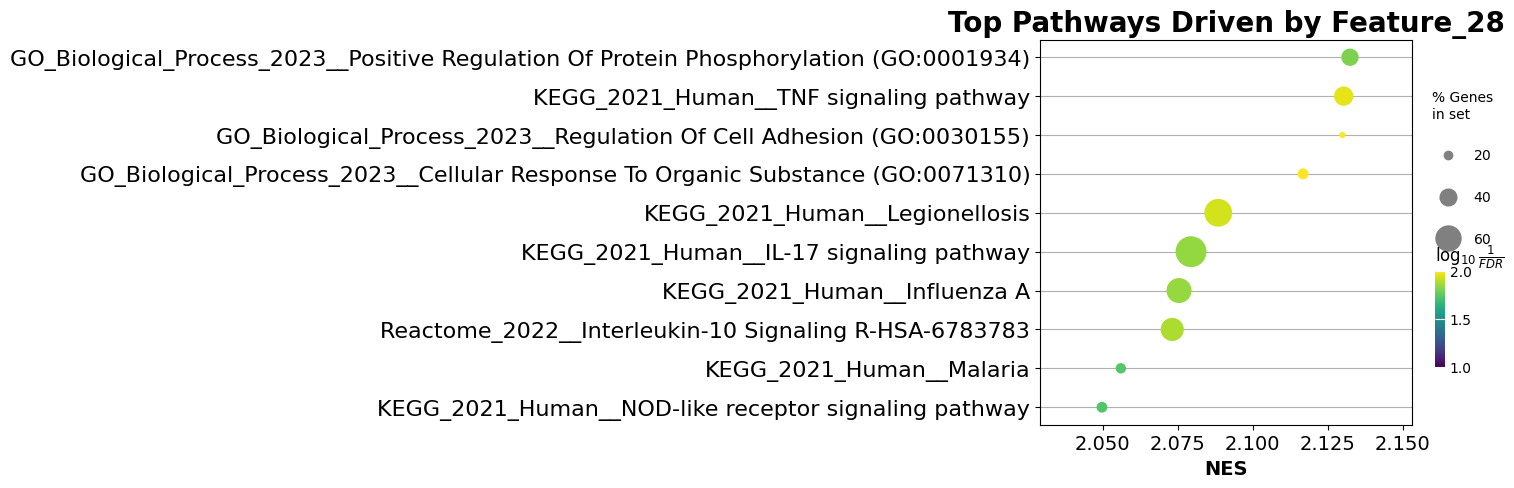

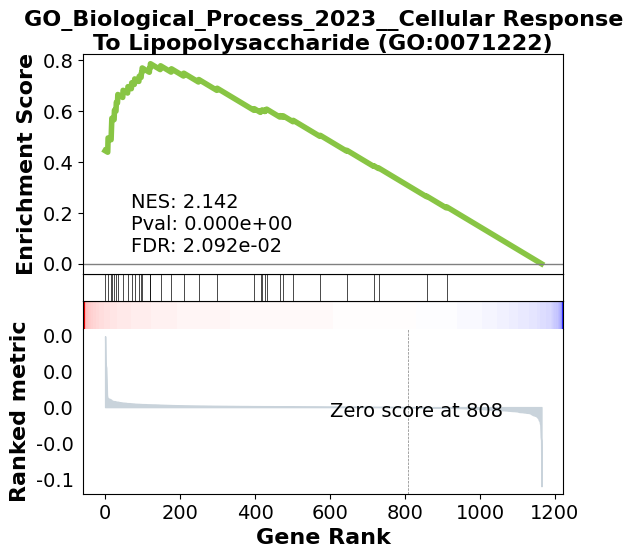

In [28]:
import gseapy as gp

def run_gsea_on_attribution(consensus_genes_df, outdir="data/IBD_Andre_data_filtered/gsea_results"):
    """
    Runs Pre-ranked GSEA on the consensus attribution scores.
    """
    os.makedirs(outdir, exist_ok=True)
    
    # 1. Format the data for GSEAPy Prerank
    # We need exactly 2 columns: Gene and Score, sorted by Score descending
    rnk = consensus_genes_df[["Gene", "Mean_Attribution"]].copy()
    
    # Gene names usually need to be uppercase for human gene set libraries
    rnk["Gene"] = rnk["Gene"].astype(str).str.upper() 
    
    # Sort descending so the strongest drivers are at the top of the ranked list
    rnk = rnk.sort_values(by="Mean_Attribution", ascending=False).reset_index(drop=True)
    
    # 2. Select Gene Set Libraries
    # These are highly relevant for IBD / Immune responses
    gene_sets = ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']
    
    print("Running Pre-ranked GSEA... This might take a minute.")
    pre_res = gp.prerank(
        rnk=rnk,
        gene_sets=gene_sets,
        threads=4,
        min_size=5,      # Ignore pathways with fewer than 5 genes
        max_size=1000,   # Ignore overly generic pathways with > 1000 genes
        outdir=outdir,
        seed=42
    )
    
    # Extract the results dataframe
    res_df = pre_res.res2d
    
    # Filter for statistically significant pathways (FDR < 0.05)
    sig_res = res_df[res_df["FDR q-val"] < 0.05].sort_values(by="NES", ascending=False)
    
    return sig_res, pre_res, rnk

sig_pathways, gsea_obj, ranked_genes = run_gsea_on_attribution(consensus_genes)

print(f"\nTop 10 Enriched Pathways for {top_feature}:")
# Displaying Term, Normalized Enrichment Score (NES), and False Discovery Rate
print(sig_pathways[['Term', 'NES', 'FDR q-val']].head(10))

if not sig_pathways.empty:
    # 1. Dotplot of top pathways
    ax = gp.dotplot(
        gsea_obj.res2d,
        column="FDR q-val",
        title=f"Top Pathways Driven by {top_feature}",
        cmap=plt.cm.viridis,
        size=5, # number of top pathways to show
        figsize=(6, 5)
    )
    plt.show()
    
    # 2. Classic GSEA Enrichment Plot for the absolute top pathway
    top_pathway_term = sig_pathways.iloc[0]["Term"]
    fig = gp.plot.gseaplot(
        rank_metric=gsea_obj.ranking, 
        term=top_pathway_term, 
        **gsea_obj.results[top_pathway_term]
    )
    plt.show()
else:
    print("No pathways reached statistical significance (FDR < 0.05).")